# 1) Chargement des données

Allez, cadeau 😘:

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

DATA_PATH = "C:/Users/Utilisateur/Desktop/OpenClassRooms/Projet 12/billets.csv"

if not os.path.exists(DATA_PATH):
    print(f"❌ Attention : le fichier '{DATA_PATH}' n'existe pas.")

try:
    df = pd.read_csv(DATA_PATH, sep=";")
    print("✅ Données chargées :", df.shape)
    display(df.head())
except Exception as e:
    print("❌ Erreur lors du chargement :", e)
    print("⚠️ Tu as bien lu le code avant de l'executer ? 😏")


✅ Données chargées : (1500, 7)


,is_genuine,diagonal,height_left,height_right,margin_low,margin_up,length
0,True,171.81,104.86,104.95,4.52,2.89,112.83
1,True,171.46,103.36,103.66,3.77,2.99,113.09
2,True,172.69,104.48,103.50,4.40,2.94,113.16
3,True,171.36,103.91,103.94,3.62,3.01,113.51
4,True,171.73,104.28,103.46,4.04,3.48,112.54


In [2]:
# Préparer seaborn
sns.set()

In [3]:
# Visualiser les vrais et faux billets

df['is_genuine'].value_counts()

is_genuine
True     1000
False     500
Name: count, dtype: int64

# 2) Analyse exploratoire (EDA)


Là, c'est vous les pro 💪, je vous fais entièrement confiance 😉 !

Pssst (indice) : trouvez des variables corrélées à votre objectif, ça marche mieux 😉.

## Fichier global

In [4]:
# Type de données
df.dtypes

is_genuine         bool
diagonal        float64
height_left     float64
height_right    float64
margin_low      float64
margin_up       float64
length          float64
dtype: object

In [5]:
# Doublons
df.duplicated().sum()

np.int64(0)

In [6]:
# Valeurs manquantes
df.count()

is_genuine      1500
diagonal        1500
height_left     1500
height_right    1500
margin_low      1463
margin_up       1500
length          1500
dtype: int64

In [7]:
# Affichage des valeurs manquantes

df[df['margin_low'].isna()]

,is_genuine,diagonal,height_left,height_right,margin_low,margin_up,length
72,True,171.94,103.89,103.45,NaN,3.25,112.79
99,True,171.93,104.07,104.18,NaN,3.14,113.08
151,True,172.07,103.80,104.38,NaN,3.02,112.93
197,True,171.45,103.66,103.80,NaN,3.62,113.27
241,True,171.83,104.14,104.06,NaN,3.02,112.36
251,True,171.80,103.26,102.82,NaN,2.95,113.22
284,True,171.92,103.83,103.76,NaN,3.23,113.29
334,True,171.85,103.70,103.96,NaN,3.00,113.36
410,True,172.56,103.72,103.51,NaN,3.12,112.95
413,True,172.30,103.66,103.50,NaN,3.16,112.95


In [8]:
# Statistiques descriptives
df.describe()

,diagonal,height_left,height_right,margin_low,margin_up,length
count,1500.000000,1500.000000,1500.000000,1463.000000,1500.000000,1500.00000
mean,171.958440,104.029533,103.920307,4.485967,3.151473,112.67850
std,0.305195,0.299462,0.325627,0.663813,0.231813,0.87273
min,171.040000,103.140000,102.820000,2.980000,2.270000,109.49000
25%,171.750000,103.820000,103.710000,4.015000,2.990000,112.03000
50%,171.960000,104.040000,103.920000,4.310000,3.140000,112.96000
75%,172.170000,104.230000,104.150000,4.870000,3.310000,113.34000
max,173.010000,104.880000,104.950000,6.900000,3.910000,114.44000


Caractéristiques de diagonal
count    1500.000000
mean      171.958440
std         0.305195
min       171.040000
25%       171.750000
50%       171.960000
75%       172.170000
max       173.010000
Name: diagonal, dtype: float64
Test Shapiro : 0.9986864738301715
Valeur P : 0.32408512787981414


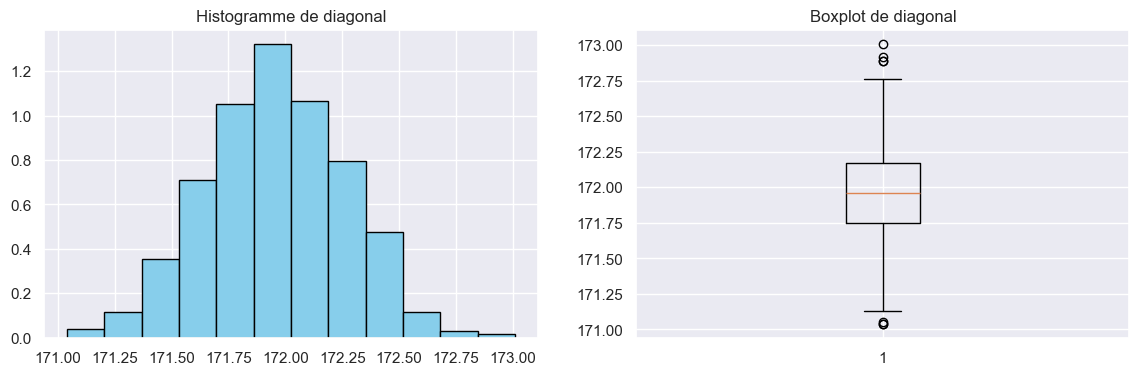

Caractéristiques de height_left
count    1500.000000
mean      104.029533
std         0.299462
min       103.140000
25%       103.820000
50%       104.040000
75%       104.230000
max       104.880000
Name: height_left, dtype: float64
Test Shapiro : 0.9979048516498805
Valeur P : 0.05141612273447701


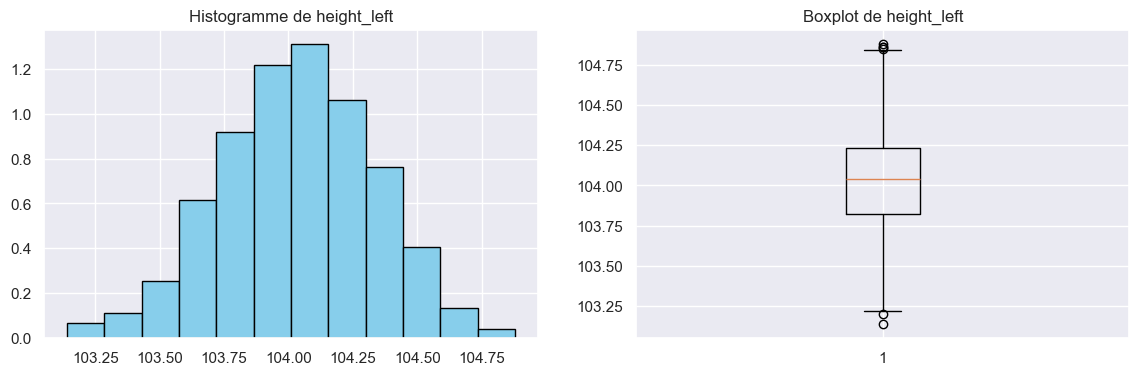

Caractéristiques de height_right
count    1500.000000
mean      103.920307
std         0.325627
min       102.820000
25%       103.710000
50%       103.920000
75%       104.150000
max       104.950000
Name: height_right, dtype: float64
Test Shapiro : 0.9995154560998667
Valeur P : 0.979977790234209


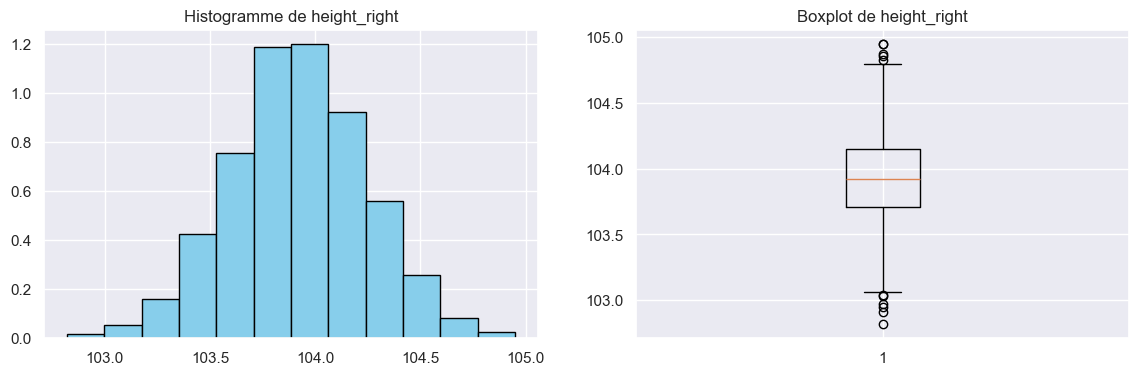

Caractéristiques de margin_low
count    1463.000000
mean        4.485967
std         0.663813
min         2.980000
25%         4.015000
50%         4.310000
75%         4.870000
max         6.900000
Name: margin_low, dtype: float64
Test Shapiro : 0.9377844940452797
Valeur P : 2.82931851362892e-24


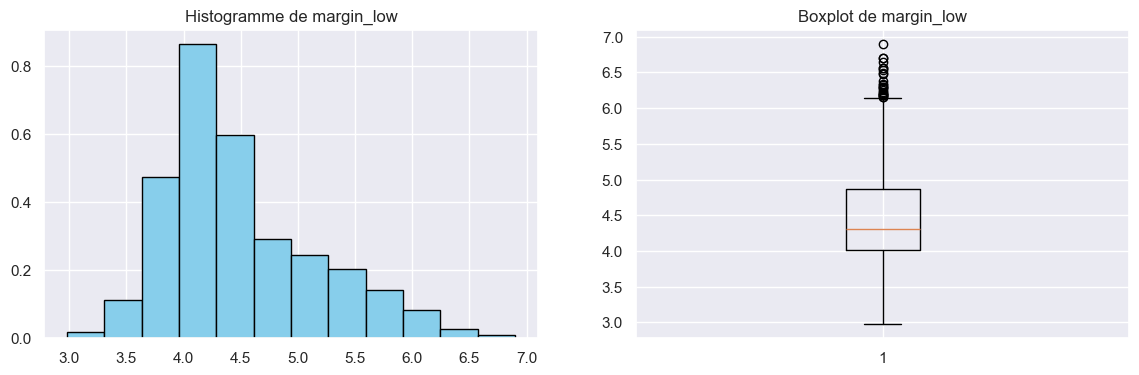

Caractéristiques de margin_up
count    1500.000000
mean        3.151473
std         0.231813
min         2.270000
25%         2.990000
50%         3.140000
75%         3.310000
max         3.910000
Name: margin_up, dtype: float64
Test Shapiro : 0.9961647384349555
Valeur P : 0.0008086307957695022


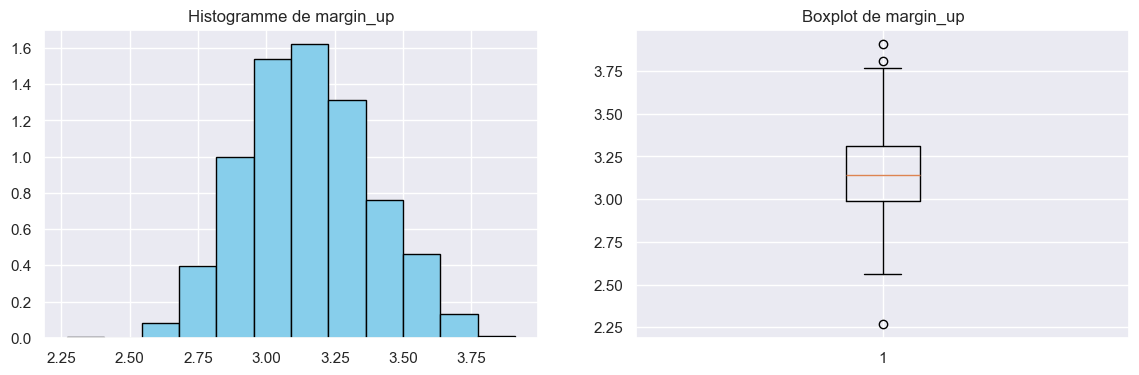

Caractéristiques de length
count    1500.00000
mean      112.67850
std         0.87273
min       109.49000
25%       112.03000
50%       112.96000
75%       113.34000
max       114.44000
Name: length, dtype: float64
Test Shapiro : 0.9175992755377756
Valeur P : 7.859411012882805e-28


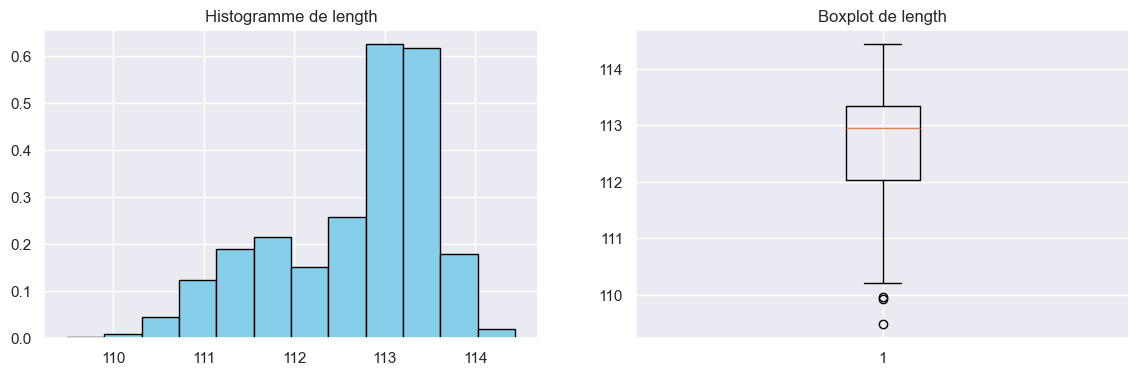

In [9]:
# Afficher la distribution et les caractéristiques des variables + test de Shapiro Wilk

from scipy.stats import shapiro


for col in df :
    if df[col].dtype != 'bool' :                       # Sortir la colonne booleenne
        print(f'Caractéristiques de {col}')
        print(df[col].describe())
        fig, ax = plt.subplots(1, 2, figsize=(14,4))
        ax[0].hist(df[col],                            # Histogramme
                   bins=12,                            # Bins = 1 + log2(1500)
                   density=True,
                   color='skyblue', 
                   edgecolor='black')
        ax[0].set_title(f'Histogramme de {col}')
        ax[1].boxplot(df[col].dropna())                # Boxplot
        ax[1].set_title(f'Boxplot de {col}')
        stat, p_value = shapiro(df[col].dropna())      # Test Shapiro
        print(f'Test Shapiro : {stat}')
        print(f'Valeur P : {p_value}')
            
        plt.show()

In [10]:
# Visualiser les outliers
    
for col in df :
    if df[col].dtype != 'bool':
        q1 = df[col].quantile(0.25)
        q3 = df[col].quantile(0.75)
        iqr = q3 -q1
        df_outliers = df[(df[col] < q1 - 1.5 * iqr) | (df[col] > q1 + 1.5 * iqr)]
             
        print(f'Nb outliers {col} : {df_outliers.shape[0]}')
        print(f'Nombre de vrais et faux billets sur les outliers {col} :')
        print(df_outliers['is_genuine'].value_counts())
        display(df_outliers.sort_values(col))


    

Nb outliers diagonal : 134
Nombre de vrais et faux billets sur les outliers diagonal :
is_genuine
True     102
False     32
Name: count, dtype: int64


,is_genuine,diagonal,height_left,height_right,margin_low,margin_up,length
1142,False,171.04,104.23,104.22,4.87,3.56,111.54
729,True,171.04,103.84,103.64,4.22,3.36,112.70
1388,False,171.05,104.09,104.50,4.72,3.10,112.44
1257,False,172.39,104.34,104.10,5.89,3.14,111.56
899,True,172.39,103.98,104.05,4.26,2.98,113.41
...,...,...,...,...,...,...,...
231,True,172.76,104.22,104.00,4.20,3.27,113.69
842,True,172.89,103.77,104.24,4.12,3.01,113.72
1022,False,172.89,104.03,104.03,6.03,3.00,110.95
828,True,172.92,103.55,103.94,4.78,3.27,113.55


Nb outliers height_left : 137
Nombre de vrais et faux billets sur les outliers height_left :
is_genuine
False    69
True     68
Name: count, dtype: int64


,is_genuine,diagonal,height_left,height_right,margin_low,margin_up,length
292,True,172.09,103.14,103.81,4.88,3.01,113.69
224,True,172.12,103.20,103.92,4.46,3.26,113.44
182,True,171.94,104.44,104.13,3.32,3.02,113.49
810,True,172.17,104.44,103.31,4.15,3.31,112.96
681,True,172.49,104.44,103.98,4.08,3.07,113.16
...,...,...,...,...,...,...,...
1310,False,171.92,104.84,104.60,5.96,2.92,110.69
1382,False,171.97,104.85,104.52,5.87,3.56,110.98
0,True,171.81,104.86,104.95,4.52,2.89,112.83
1150,False,171.79,104.86,104.34,5.39,3.14,113.02


Nb outliers height_right : 128
Nombre de vrais et faux billets sur les outliers height_right :
is_genuine
False    96
True     32
Name: count, dtype: int64


...

,is_genuine,diagonal,height_left,height_right,margin_low,margin_up,length
1431,False,172.52,104.11,104.35,5.30,3.31,111.55
1030,False,171.96,104.45,104.48,5.31,3.42,111.75
1373,False,171.69,104.17,104.37,5.31,3.54,111.89
1217,False,171.63,104.61,104.29,5.31,3.14,111.51
1129,False,171.68,104.04,104.68,5.32,3.56,111.04
...,...,...,...,...,...,...,...
1441,False,171.63,104.55,103.81,6.56,3.10,111.87
1041,False,171.77,104.12,104.42,6.65,3.63,111.53
1027,False,171.63,104.02,104.66,6.70,3.28,111.28
1124,False,171.88,103.92,104.27,6.70,3.11,110.93


Nb outliers margin_up : 148
Nombre de vrais et faux billets sur les outliers margin_up :
is_genuine
False    133
True      15
Name: count, dtype: int64


,is_genuine,diagonal,height_left,height_right,margin_low,margin_up,length
664,True,172.05,103.70,103.75,5.04,2.27,113.55
1002,False,171.59,104.14,104.38,4.97,3.47,111.22
1096,False,172.34,104.36,103.82,4.92,3.47,111.33
1080,False,172.23,103.83,104.29,5.61,3.47,111.72
1113,False,171.84,104.52,104.19,4.60,3.47,110.64
...,...,...,...,...,...,...,...
1297,False,171.96,104.47,104.06,4.84,3.76,111.04
1478,False,172.36,103.93,104.00,6.08,3.76,112.89
1199,False,172.03,104.32,104.87,4.49,3.77,111.04
1270,False,171.26,104.22,104.07,4.78,3.81,112.88


Nb outliers length : 16
Nombre de vrais et faux billets sur les outliers length :
is_genuine
True     13
False     3
Name: count, dtype: int64


,is_genuine,diagonal,height_left,height_right,margin_low,margin_up,length
1082,False,171.75,103.96,103.83,5.39,3.54,109.49
1453,False,171.55,104.20,104.49,5.42,3.54,109.93
1355,False,171.68,103.89,103.70,5.97,3.03,109.97
447,True,171.59,103.86,104.33,4.12,2.84,114.00
458,True,172.00,104.07,103.55,3.86,3.30,114.03
170,True,171.62,104.41,103.71,4.13,3.21,114.03
106,True,172.27,103.95,103.75,3.94,3.19,114.04
149,True,171.91,103.97,103.60,4.66,3.03,114.04
536,True,172.38,103.64,103.81,4.46,3.14,114.07
203,True,172.33,104.18,104.04,4.29,2.99,114.08


In [11]:
# Les outliers semblent être des valeurs atypiques. 
# Les outliers concernant la variable margin_low indiquent tous de faux billets

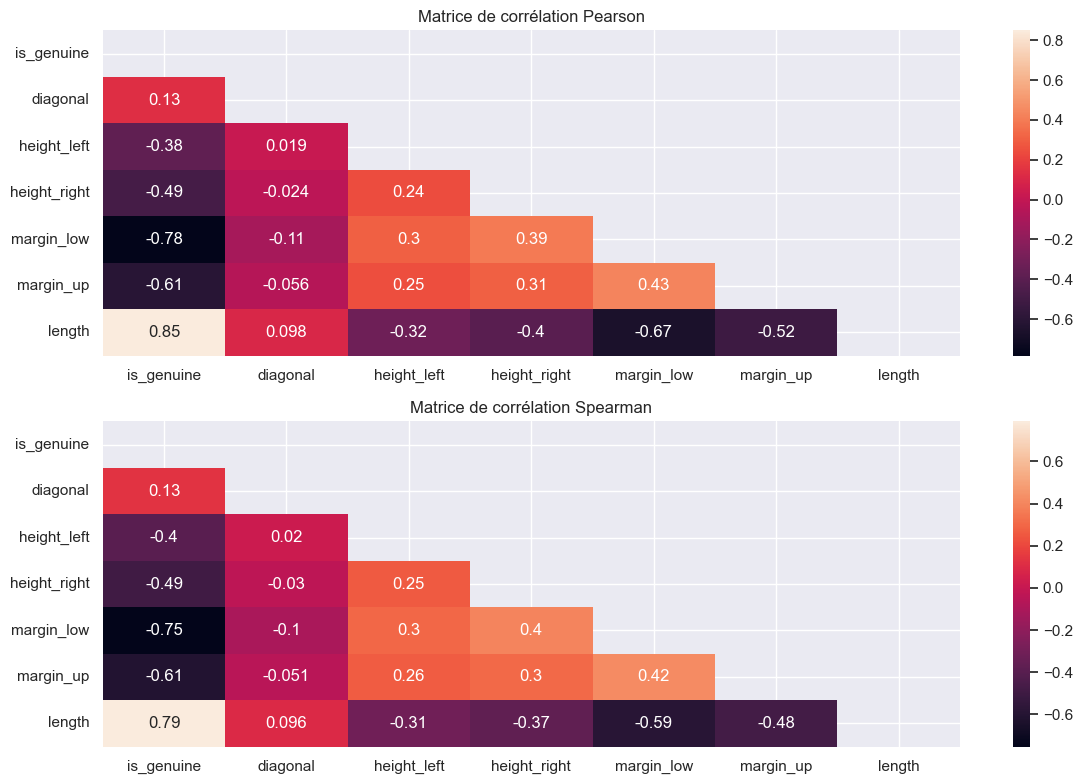

In [12]:
# Matrice de corrélation Pearson & Spearman

corr_p = df.corr(method='pearson').dropna()
corr_s = df.corr(method = 'spearman').dropna()

mask_p = np.triu(np.ones_like(corr_p, dtype=bool)) # Mask pour la diagonale
mask_s = np.triu(np.ones_like(corr_s, dtype=bool))

fig, ax = plt.subplots(2, 1, figsize=(12,8))

sns.heatmap(corr_p,
           annot=True,
            mask=mask_p,
            ax=ax[0]
           )

ax[0].set_title('Matrice de corrélation Pearson')

sns.heatmap(corr_s,
              annot=True,
              mask=mask_s,
            ax=ax[1]
             )

ax[1].set_title('Matrice de corrélation Spearman')

plt.tight_layout()
plt.show()

In [13]:
# Les 2 matrices sont assez proches
# Lorsque la longueur du billet augmente le billet à tendance à être vrai
# Lorsque les marges hautes et basses augementent, le billet à tendance à être faux

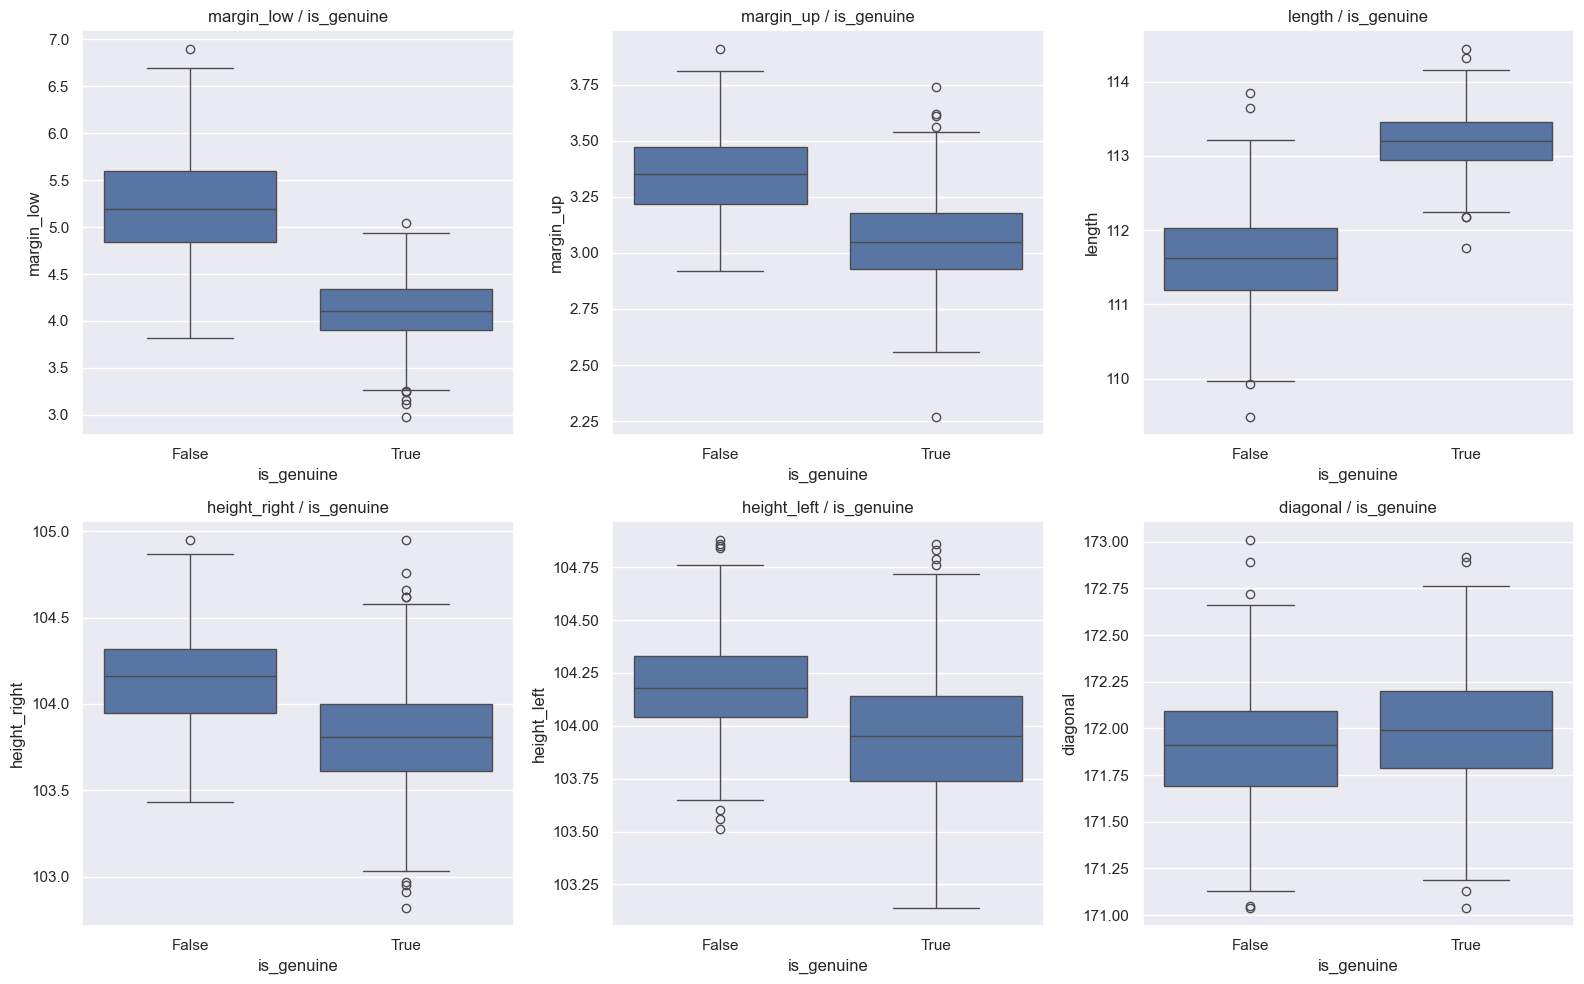

In [14]:
# Visualisation de la distribution des variables prédictrices selon la variable cible is_genuine avec des boxplots

fig, ax = plt.subplots(2, 3, figsize=(16, 10))

sns.boxplot(data=df, x='is_genuine', y='margin_low', ax=ax[0, 0])
ax[0, 0].set_title('margin_low / is_genuine')

sns.boxplot(data=df, x='is_genuine', y='margin_up', ax=ax[0, 1])
ax[0, 1].set_title('margin_up / is_genuine')

sns.boxplot(data=df, x='is_genuine', y='length', ax=ax[0, 2])
ax[0, 2].set_title('length / is_genuine')

sns.boxplot(data=df, x='is_genuine', y='height_right', ax=ax[1, 0])
ax[1, 0].set_title('height_right / is_genuine')

sns.boxplot(data=df, x='is_genuine', y='height_left', ax=ax[1, 1])
ax[1, 1].set_title('height_left / is_genuine')

sns.boxplot(data=df, x='is_genuine', y='diagonal', ax=ax[1, 2])
ax[1, 2].set_title('diagonal / is_genuine')

plt.tight_layout()

plt.savefig('distri_sur_cible.png', dpi=300, bbox_inches='tight')
plt.show()

In [15]:
# Le constat est que les vrais billets ont tendance à avoir des marges plus courtes entre les bords et l'image,
# à être plus long, et à avoir une hauteur plus longue à droite et à gauche. La diagonale ne semble pas discriminante.

In [16]:
# Gestion des NaN de margin low => Vérification des conditions d'utilisations d'une regression linéaire

# Séparer les df => lignes complètes et incomplètes
df_complet = df[~df['margin_low'].isna()]
df_incomplet = df[df['margin_low'].isna()]


# stocker describe pour la comparaison avant après
margin_low_nan = df['margin_low'].describe()
box_margin_low = df['margin_low']

Corrélation Pearson margin_low / length -0.6667527808936001
Valeur p : 8.975567091012927e-189


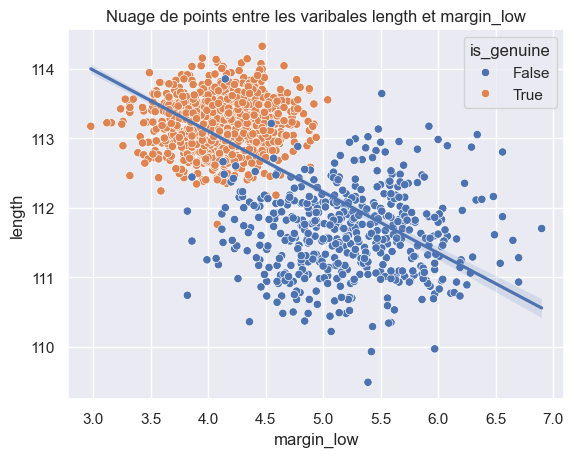

In [17]:
from scipy.stats import pearsonr

stat, p_value = pearsonr(df_complet['margin_low'], df_complet['length'])
print(f'Corrélation Pearson margin_low / length {stat}')
print(f'Valeur p : {p_value}')

# Visualisation de la linéarité entre les variables => Scatterplot avec les varibales corrélés sur les matrices

sns.scatterplot(data=df, x='margin_low', y='length', hue='is_genuine')
sns.regplot(data=df, x='margin_low', y='length', scatter=False)
plt.title('Nuage de points entre les varibales length et margin_low')
plt.show()

In [18]:
# Une relation linéaire modérée à forte existe entre length et margin_low. La valeur p indique une relation significative statistiquement.

Corrélation Pearson margin_low / margin_up 0.4316060733203143
Valeur p : 1.92160401830609e-67


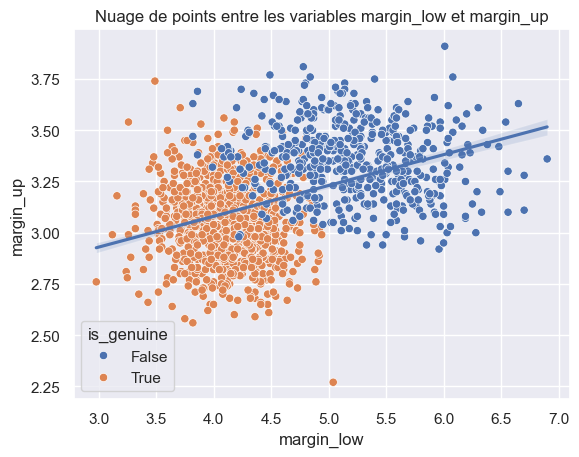

In [19]:
stat, p_value = pearsonr(df_complet['margin_low'], df_complet['margin_up'])
print(f'Corrélation Pearson margin_low / margin_up {stat}')
print(f'Valeur p : {p_value}')

sns.scatterplot(data=df, x='margin_low', y='margin_up', hue='is_genuine')
sns.regplot(data=df, x='margin_low', y='margin_up', scatter=False)
plt.title('Nuage de points entre les variables margin_low et margin_up')

plt.show()

In [20]:
# Une relation linéaire modérée existe entre margin_up et margin_low. La valeur p indique une relation significative statistiquement.

In [21]:
# Regression linéaire simple avec length

import statsmodels.formula.api as smf

model = smf.ols("margin_low ~ length", data=df_complet).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:             margin_low   R-squared:                       0.445
Model:                            OLS   Adj. R-squared:                  0.444
Method:                 Least Squares   F-statistic:                     1169.
Date:                Wed, 03 Jun 2026   Prob (F-statistic):          8.98e-189
Time:                        13:31:41   Log-Likelihood:                -1045.8
No. Observations:                1463   AIC:                             2096.
Df Residuals:                    1461   BIC:                             2106.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     61.5960      1.670     36.881      0.0

In [22]:
# length est une bonne variable explicative, mais insuffisante seule pour une imputation robuste

In [23]:
# Modèle avec length + margin_up
model2 = smf.ols("margin_low ~ length + margin_up", data=df_complet).fit()
print(model2.summary())

                            OLS Regression Results                            
Dep. Variable:             margin_low   R-squared:                       0.454
Model:                            OLS   Adj. R-squared:                  0.454
Method:                 Least Squares   F-statistic:                     607.7
Date:                Wed, 03 Jun 2026   Prob (F-statistic):          9.76e-193
Time:                        13:31:42   Log-Likelihood:                -1032.9
No. Observations:                1463   AIC:                             2072.
Df Residuals:                    1460   BIC:                             2088.
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     55.3957      2.055     26.963      0.0

In [24]:
# Modèle avec length / margin_up / height_right / heiht_left
model3 = smf.ols("margin_low ~ length + margin_up + height_right + height_left", data=df_complet).fit()
print(model3.summary())

                            OLS Regression Results                            
Dep. Variable:             margin_low   R-squared:                       0.475
Model:                            OLS   Adj. R-squared:                  0.473
Method:                 Least Squares   F-statistic:                     329.5
Date:                Wed, 03 Jun 2026   Prob (F-statistic):          4.80e-202
Time:                        13:31:42   Log-Likelihood:                -1004.9
No. Observations:                1463   AIC:                             2020.
Df Residuals:                    1458   BIC:                             2046.
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
Intercept        5.2656      7.048      0.747   

In [25]:
# L’ajout des variables height_left et height_right améliore légèrement la performance du modèle (R² passant de 0.454 à 0.475). 
# Toutefois, cette amélioration s’accompagne d’une augmentation importante de la multicolinéarité, 
# suggérant des redondances entre variables explicatives.

# Le modèle à deux variables (length et margin_up) est retenu comme modèle final d’imputation, 
# car il offre un bon compromis entre performance explicative et stabilité statistique, 
# malgré un R² légèrement inférieur au modèle complet.

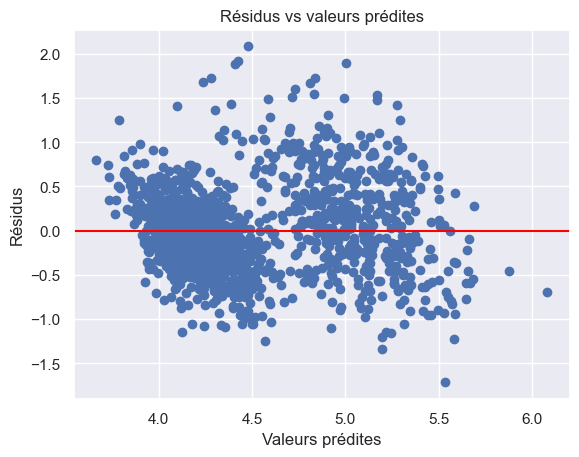

In [26]:
# Imputation des valeurs manquantes

model = smf.ols("margin_low ~ length + margin_up", data=df_complet).fit()

residuals = model.resid
y_pred = model.fittedvalues

plt.scatter(y_pred, residuals)
plt.axhline(0, color='red')
plt.xlabel("Valeurs prédites")
plt.ylabel("Résidus")
plt.title("Résidus vs valeurs prédites")
plt.show()

In [27]:
# Test Shapiro sur les résidus

stat, p_value = shapiro(residuals)
print(stat)
print(p_value)

0.9835276366015221
7.061289084600442e-12


In [28]:
# Le test de Shapiro indique une non-normalité statistique des résidus (p-value < 0.05). 
# Toutefois, compte tenu de la taille importante de l’échantillon, ce test est très sensible aux faibles écarts à la normalité. 
# L’analyse graphique des résidus ne montre pas de structure particulière ni de violation majeure des hypothèses de la régression linéaire.

In [29]:
from statsmodels.stats.diagnostic import het_breuschpagan

bp_test = het_breuschpagan(model.resid, model.model.exog)

labels = ['LM Statistic', 'LM-Test p-value', 'F-Statistic', 'F-Test p-value']

for label, value in zip(labels, bp_test):
    print(f"{label} : {value}")

LM Statistic : 69.18185711374537
LM-Test p-value : 9.49184426089401e-16
F-Statistic : 36.233389521286675
F-Test p-value : 4.386363638505571e-16


In [30]:
# Le test de Breusch-Pagan met en évidence une hétéroscédasticité des résidus (p-value < 0.05). 
# Toutefois, l’analyse graphique des résidus ne révèle pas de structure majeure, et les distributions avant/après imputation restent très proches.
# Le modèle est donc considéré comme suffisamment robuste pour réaliser l’imputation des valeurs manquantes.

In [31]:
# Imputation des valeurs manquantes

mask = df['margin_low'].isna()
df.loc[mask, 'margin_low'] = model.predict(df.loc[mask])

In [32]:
# Vérification du nb de ligne

df.count()

is_genuine      1500
diagonal        1500
height_left     1500
height_right    1500
margin_low      1500
margin_up       1500
length          1500
dtype: int64

In [33]:
# Comparaison des describe

print(f'Avant imputation : \n{margin_low_nan}')
print(f'\nAprès imputation : \n{df['margin_low'].describe()}')

Avant imputation : 
count    1463.000000
mean        4.485967
std         0.663813
min         2.980000
25%         4.015000
50%         4.310000
75%         4.870000
max         6.900000
Name: margin_low, dtype: float64

Après imputation : 
count    1500.000000
mean        4.483708
std         0.659198
min         2.980000
25%         4.020000
50%         4.315000
75%         4.870000
max         6.900000
Name: margin_low, dtype: float64


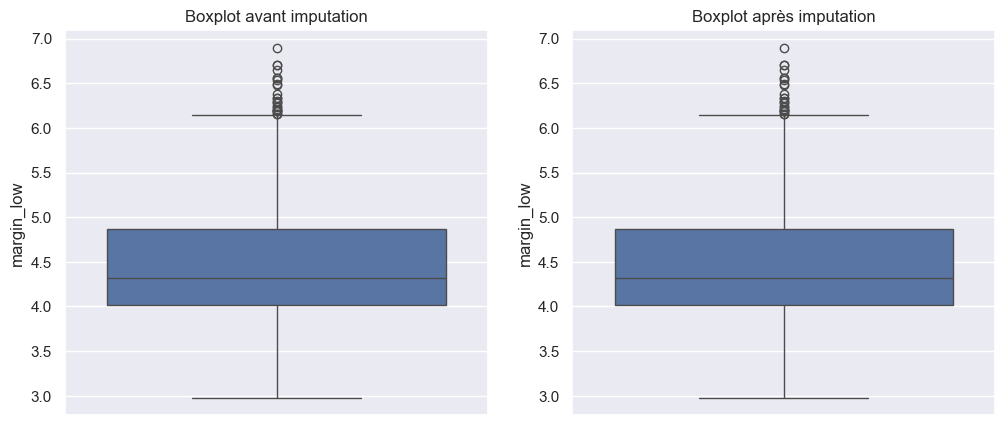

In [34]:
# Comparaison des distributions avant / après avec un boxplot

fig, ax = plt.subplots(1, 2, figsize=(12, 5))
sns.boxplot(data=box_margin_low, ax=ax[0])
ax[0].set_title('Boxplot avant imputation')
sns.boxplot(df, y='margin_low', ax=ax[1])
ax[1].set_title('Boxplot après imputation')
plt.show()

# 3) Prétraitement

Le but est de transformer tes données brutes (les valeurs mesurées des billets) en données que les algorithmes de Machine Learning peuvent comprendre efficacement.


D'abord, il faut séparer les variables explicatives et la cible :

X = les mesures du billet (longueur, hauteur, diagonales…)

y = l’étiquette (vrai ou faux)

➡️ Pourquoi ?
Parce que le modèle doit apprendre à prédire y en fonction de X.

In [35]:
X = df.drop('is_genuine', axis=1) # Toutes les colonnes sauf la cible
y = df['is_genuine'] # La colonne cible

Autre point important : on entraîne toujours le modèle sur un morceau des données, et on teste sur un autre qu’il n’a jamais vu.

➡️ Pourquoi ?
Pour éviter le sur-apprentissage (le modèle apprend par cœur sans savoir généraliser).

In [36]:
# Séparer les données d'entrainements des données de test

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42) # utilisez train_test_split de la librairy Sklearn

Enfin, on met toutes les variables sur la même échelle (moyenne = 0, écart-type = 1).

➡️ Pourquoi ?
Parce que certains modèles, comme le KNN ou la Régression Logistique, sont sensibles aux différences d’échelle.
Sans standardisation, la variable la plus grande numériquement prend trop d’importance.

In [37]:
# Standardiser les données

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
# Use scaler on X_train and X_test.

# Entraîner le modèle sur train
scaler.fit(X_train)   

# Transformer les données sur X_train, X_test
X_train = scaler.transform(X_train)
X_test = scaler.transform(X_test)

In [38]:
# Vérification des moyenne & écart type des nouvelles valeurs

train = pd.DataFrame(X_train, columns=[df.columns.drop('is_genuine')])
idx = ['mean', 'std']
train.describe().loc[idx].round(2)

,diagonal,height_left,height_right,margin_low,margin_up,length
mean,0.0,-0.0,0.0,0.0,0.0,-0.0
std,1.0,1.0,1.0,1.0,1.0,1.0


# 4) Modélisation

Dans tous domaines, vous ne pouvez pas progresser si vous ne comprenez pas comment vos outils fonctionnent.

Avant d'utiliser les modèles mathématiques qui suivent, je vous recommande donc de visionner les vidéos suivantes:
* [StatQuest: Logistic Regression](https://www.youtube.com/watch?v=yIYKR4sgzI8)
* [StatQuest: K-nearest neighbors, Clearly Explained](https://youtu.be/HVXime0nQeI)
* [StatQuest: Random Forests Part 1 - Building, Using and Evaluating](https://youtu.be/J4Wdy0Wc_xQ)
* [StatQuest: Random Forests Part 2: Missing data and clustering](https://www.youtube.com/watch?v=sQ870aTKqiM)
* [StatQuest: K-means clustering](https://youtu.be/4b5d3muPQmA)

### Import des différents métrics

In [39]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, ConfusionMatrixDisplay, classification_report

## Regression logistique

In [40]:
from sklearn.linear_model import LogisticRegression

# 1) Initialisez une régression logistic.
clf = LogisticRegression(random_state=42, max_iter=1000)

    # Quels sont les paramètres ajustables de ce modèle ?

# C → complexité
# max_iter → temps d’apprentissage
# penalty → régularisation
# class_weight → équilibre des classe


    # Bien que vous puissez laisser la majorité d'entre eux par défaut,
    # il vaut mieux, à minima, ajuster `max_iter` pour plafonner le temps de calcul.


# 2) Entrainez le modèle avec vos données X_train et y_train
clf.fit(X_train, y_train)

# 3) Utiliser la régression logistique pour déterminer les vrais / faux billets de X_test.
y_pred_clf = clf.predict(X_test)

In [41]:
# Visualiser le poids des variables dans la détection des faux billets

label = df.columns.drop(['is_genuine'])

coeff_clf = pd.DataFrame(clf.coef_, columns=label)
coeff_clf

,diagonal,height_left,height_right,margin_low,margin_up,length
0,0.093763,-0.475537,-0.723736,-2.575247,-1.565738,3.539221


In [42]:
# La longueur du billet à un fort impact sur la véracité du billet, plus il est long, plus il y a de probalité qu'il soit vrai.
# Les marges hautes (fort) et basses (assez fort) ont egalement un impact, plus leurs valeurs sont grandes, plus il y a de 
# probabilités que le billet soit faux.

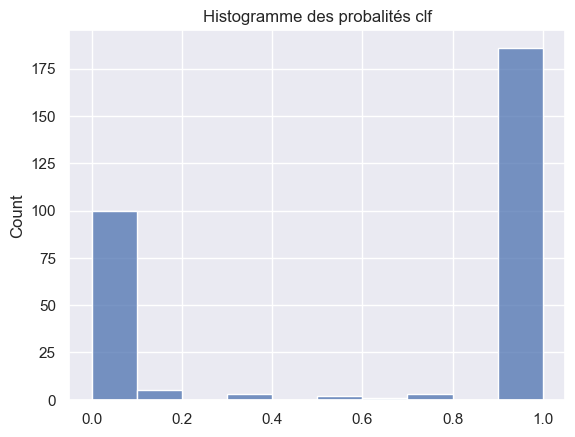

In [43]:
# Histogramme des probabilités
y_hat_proba_clf = clf.predict_proba(X_test)[:, 1]
sns.histplot(y_hat_proba_clf, bins=10)
plt.title('Histogramme des probalités clf')
plt.show()

In [44]:
# Matrice de confusion
cm_clf = confusion_matrix(y_test, y_pred_clf, labels=clf.classes_)
print('Matrice de confusion clf :')
print(cm_clf)

Matrice de confusion clf :
[[108   2]
 [  0 190]]


In [45]:
# Rapport par classe sur les données tests
print('Rapport sur les prédictions des données tests clf :')
print(classification_report(y_test, y_pred_clf))

Rapport sur les prédictions des données tests clf :
              precision    recall  f1-score   support

       False       1.00      0.98      0.99       110
        True       0.99      1.00      0.99       190

    accuracy                           0.99       300
   macro avg       0.99      0.99      0.99       300
weighted avg       0.99      0.99      0.99       300



In [46]:
# Rapport par classe sur les odnnées train
y_pred_train_clf = clf.predict(X_train)
print('Rapport sur les prédictions des données train clf')
print(classification_report(y_train, y_pred_train_clf))

Rapport sur les prédictions des données train clf
              precision    recall  f1-score   support

       False       0.99      0.98      0.99       390
        True       0.99      1.00      0.99       810

    accuracy                           0.99      1200
   macro avg       0.99      0.99      0.99      1200
weighted avg       0.99      0.99      0.99      1200



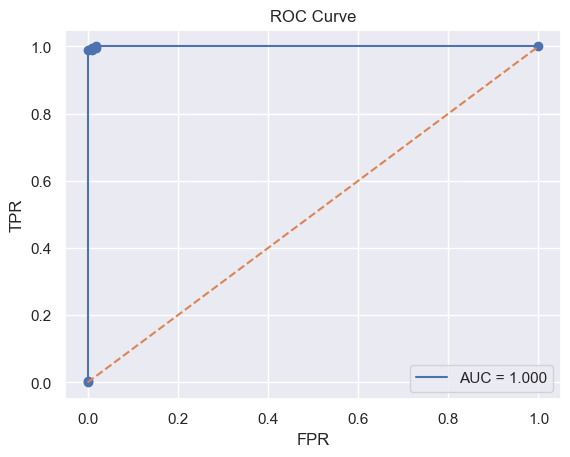

In [47]:
from sklearn.metrics import roc_curve, auc
fpr, tpr, thresholds = roc_curve(y_test, y_hat_proba_clf)
roc_auc = auc(fpr, tpr)

plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}")
plt.plot([0, 1], [0, 1], "--")

plt.xlabel("FPR")
plt.ylabel("TPR")
plt.title("ROC Curve")
plt.legend()

plt.scatter(fpr, tpr)

plt.show()

In [48]:
# Affichage des différents seuils
thresholds

array([           inf, 9.99999404e-01, 7.54945850e-01, 7.38878709e-01,
       6.80039578e-01, 5.80849088e-01, 5.09533386e-01, 1.51688484e-07])

In [49]:
# Matrice de confusion avec un seuil à 0.6
threshold = 0.6
y_pred_new = (y_hat_proba_clf >= threshold)

print(confusion_matrix(y_test, y_pred_new))

[[109   1]
 [  1 189]]


In [50]:
# Essai avec diagonale en moins (coefficient très bas)
X_train_reduced = np.delete(X_train, 0, axis=1)
X_test_reduced = np.delete(X_test, 0, axis=1)

clf.fit(X_train_reduced, y_train)
y_pred_reduced = clf.predict(X_test_reduced)

print(classification_report(y_test, y_pred_reduced))
print(confusion_matrix(y_test, y_pred_reduced))

              precision    recall  f1-score   support

       False       1.00      0.98      0.99       110
        True       0.99      1.00      0.99       190

    accuracy                           0.99       300
   macro avg       0.99      0.99      0.99       300
weighted avg       0.99      0.99      0.99       300

[[108   2]
 [  0 190]]


In [51]:
# Essai en enlevant diagonale, height_left et height_right
X_train_reduced = X_train[:, 3:]
X_test_reduced = X_test[:, 3:]

clf.fit(X_train_reduced, y_train)

y_pred_reduced = clf.predict(X_test_reduced)

print(classification_report(y_test, y_pred_reduced))
print(confusion_matrix(y_test, y_pred_reduced))

              precision    recall  f1-score   support

       False       1.00      0.98      0.99       110
        True       0.99      1.00      0.99       190

    accuracy                           0.99       300
   macro avg       0.99      0.99      0.99       300
weighted avg       0.99      0.99      0.99       300

[[108   2]
 [  0 190]]


In [52]:
# Identique au score avec toutes les variables explicatives

## KNN

In [53]:
# Répéter les même étapes que pour la régression logistique mais avec le KNN.

from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import GridSearchCV

In [54]:
# Utiliser Grid SearchCV pour trouver le meilleur nombre de k

param_grid = {'n_neighbors' : range(1, 20)}

grid = GridSearchCV(KNeighborsClassifier(), param_grid, cv=5)
grid.fit(X_train, y_train)

n_neighbors = grid.best_params_['n_neighbors']
print(n_neighbors)  

9


In [55]:
knn = KNeighborsClassifier(n_neighbors=n_neighbors)
knn.fit(X_train, y_train)

KNeighborsClassifier(n_neighbors=9)

In [56]:
y_pred_knn = knn.predict(X_test)

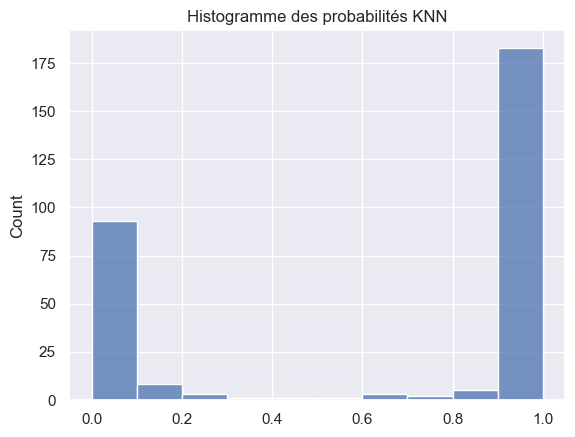

In [57]:
y_hat_proba_knn = knn.predict_proba(X_test)[:,1]
sns.histplot(y_hat_proba_knn, bins=10)
plt.title('Histogramme des probabilités KNN')

plt.show()

In [58]:
cm_knn = confusion_matrix(y_test, y_pred_knn)
print('Matrice de confusion knn(k=9) :')
print(cm_knn)

Matrice de confusion knn(k=9) :
[[106   4]
 [  0 190]]


In [60]:
print('Rapport sur les prédictions des données test knn (k=9) :')
print(classification_report(y_test, y_pred_knn))

Rapport sur les prédictions des données test knn (k=9) :
              precision    recall  f1-score   support

       False       1.00      0.96      0.98       110
        True       0.98      1.00      0.99       190

    accuracy                           0.99       300
   macro avg       0.99      0.98      0.99       300
weighted avg       0.99      0.99      0.99       300



In [811]:
y_pred_train_knn = knn.predict(X_train)
print('Rapport sur les prédictions des données train knn :')
print(classification_report(y_train, y_pred_train_clf))

Rapport sur les prédictions des données train knn :
              precision    recall  f1-score   support

       False       0.99      0.98      0.99       390
        True       0.99      1.00      0.99       810

    accuracy                           0.99      1200
   macro avg       0.99      0.99      0.99      1200
weighted avg       0.99      0.99      0.99      1200



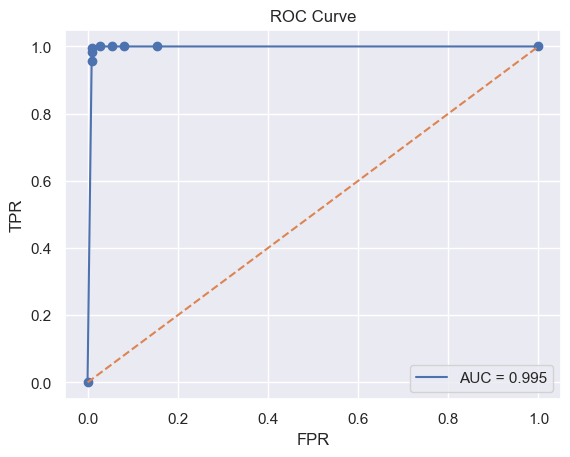

In [812]:
fpr, tpr, thresholds = roc_curve(y_test, y_hat_proba_knn)
roc_auc = auc(fpr, tpr)

plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}")
plt.plot([0, 1], [0, 1], "--")

plt.xlabel("FPR")
plt.ylabel("TPR")
plt.title("ROC Curve")
plt.legend()
plt.scatter(fpr, tpr)
plt.show()

In [813]:
thresholds

array([       inf, 1.        , 0.88888889, 0.77777778, 0.66666667,
       0.33333333, 0.22222222, 0.11111111, 0.        ])

In [814]:
threshold = 0.67
y_pred_new = (y_hat_proba_knn >= threshold)
print(confusion_matrix(y_test, y_pred_new))

[[109   1]
 [  1 189]]


In [815]:
# Essai avec seulement 3 varibales explicatives)

grid = GridSearchCV(KNeighborsClassifier(), param_grid, cv=5)
grid.fit(X_train_reduced, y_train)

n_neighbors = grid.best_params_['n_neighbors']
print(n_neighbors)

6


In [816]:
knn = KNeighborsClassifier(n_neighbors=n_neighbors)
knn.fit(X_train_reduced, y_train)

y_pred_new_knn = knn.predict(X_test_reduced)
print(classification_report(y_test, y_pred_new_knn))
print(confusion_matrix(y_test, y_pred_new_knn))

              precision    recall  f1-score   support

       False       0.99      0.99      0.99       110
        True       0.99      0.99      0.99       190

    accuracy                           0.99       300
   macro avg       0.99      0.99      0.99       300
weighted avg       0.99      0.99      0.99       300

[[109   1]
 [  1 189]]


In [817]:
# Le modèle KNN semble mieux performer avec moins de variables explicatives

## Random Forrest

In [818]:
# hum... devinez ce qu'il faut faire 😁.

from sklearn.ensemble import RandomForestClassifier
rf = RandomForestClassifier(n_estimators=100, random_state=42, max_depth=5)

rf.fit(X_train, y_train)

RandomForestClassifier(max_depth=5, random_state=42)

In [819]:
y_pred_rf = rf.predict(X_test)

In [820]:
# Importance des variables

label = df.columns.drop(['is_genuine'])
coeff_rf = pd.DataFrame(rf.feature_importances_, index=label, columns=['importance'])
coeff_rf.T

,diagonal,height_left,height_right,margin_low,margin_up,length
importance,0.005008,0.036139,0.041831,0.323378,0.104446,0.489198


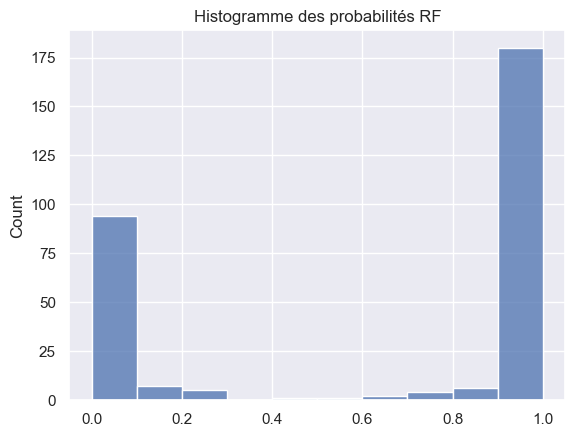

In [821]:
y_hat_proba_rf = rf.predict_proba(X_test)[:,1]
sns.histplot(y_hat_proba_rf, bins=10)
plt.title('Histogramme des probabilités RF')
plt.show()

In [714]:
cm_rf = confusion_matrix(y_test, y_pred_rf)
print('Matrice de confusion random forrest :') 
print(cm_rf)

Matrice de confusion random forrest :
[[107   3]
 [  0 190]]


In [715]:
print('Rapport sur les prédictions des données test rf')
print(classification_report(y_test, y_pred_rf))

Rapport sur les prédictions des données test rf
              precision    recall  f1-score   support

       False       1.00      0.97      0.99       110
        True       0.98      1.00      0.99       190

    accuracy                           0.99       300
   macro avg       0.99      0.99      0.99       300
weighted avg       0.99      0.99      0.99       300



In [716]:
y_pred_train_rf = rf.predict(X_train)
print('Rapport sur les prédictions des données train rf :')
print(classification_report(y_train, y_pred_train_rf))

Rapport sur les prédictions des données train rf :
              precision    recall  f1-score   support

       False       1.00      0.99      0.99       390
        True       0.99      1.00      1.00       810

    accuracy                           0.99      1200
   macro avg       1.00      0.99      0.99      1200
weighted avg       1.00      0.99      0.99      1200



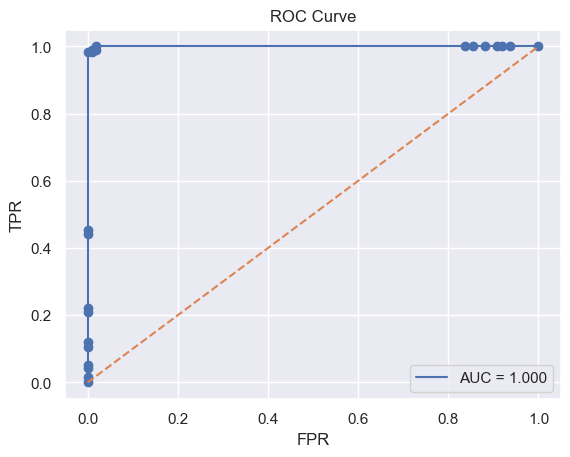

In [717]:
fpr, tpr, thresholds = roc_curve(y_test, y_hat_proba_rf)
roc_auc = auc(fpr, tpr)

plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}")
plt.plot([0, 1], [0, 1], "--")

plt.xlabel("FPR")
plt.ylabel("TPR")
plt.title("ROC Curve")
plt.legend()
plt.scatter(fpr, tpr)
plt.show()

In [718]:
thresholds

array([           inf, 9.99380774e-01, 9.99110989e-01, 9.99040360e-01,
       9.98308992e-01, 9.98291607e-01, 9.97738121e-01, 9.97724072e-01,
       9.95501303e-01, 9.95444382e-01, 7.55674963e-01, 7.41226796e-01,
       7.29414047e-01, 7.14401523e-01, 6.44919334e-01, 2.20160636e-03,
       1.94764059e-03, 1.70970814e-03, 1.43591491e-03, 1.43511855e-03,
       1.32035240e-03, 4.89945059e-04])

In [719]:
threshold = 0.64
y_pred_new = (y_hat_proba_rf >= threshold)
print(confusion_matrix(y_test, y_pred_new))

[[108   2]
 [  0 190]]


In [720]:
rf.fit(X_train_reduced, y_train)
y_pred_new_rf = rf.predict(X_test_reduced)
print(classification_report(y_test, y_pred_new_rf))
print(confusion_matrix(y_test, y_pred_new_rf))

              precision    recall  f1-score   support

       False       1.00      0.98      0.99       110
        True       0.99      1.00      0.99       190

    accuracy                           0.99       300
   macro avg       0.99      0.99      0.99       300
weighted avg       0.99      0.99      0.99       300

[[108   2]
 [  0 190]]


## Kmeans

In [721]:
from sklearn.cluster import KMeans

# Attention ! Cet algo est très différents de ceux utilisés précédemment.

# Initialisation de Kmeans avec n_clusters = 2 (variable cible binaire)
kmeans = KMeans(n_clusters=2, random_state=42, n_init=10)

In [722]:
# Initilaisation de l'ACP pour visualiser les clusters en 2D

from sklearn.decomposition import PCA

pca = PCA(n_components=2)

X_train_pca = pca.fit_transform(X_train)
X_test_pca = pca.transform(X_test)

In [723]:
# Entrainement sur le modèle
kmeans.fit(X_train_pca)

KMeans(n_clusters=2, n_init=10, random_state=42)

In [724]:
# Visualisation des centroïdes

centroids = kmeans.cluster_centers_
centroids

array([[-2.09499908, -0.08081188],
       [ 1.00105867,  0.03861454]])

In [725]:
# Prédiction

train_labels = kmeans.predict(X_train_pca)
test_labels = kmeans.predict(X_test_pca)

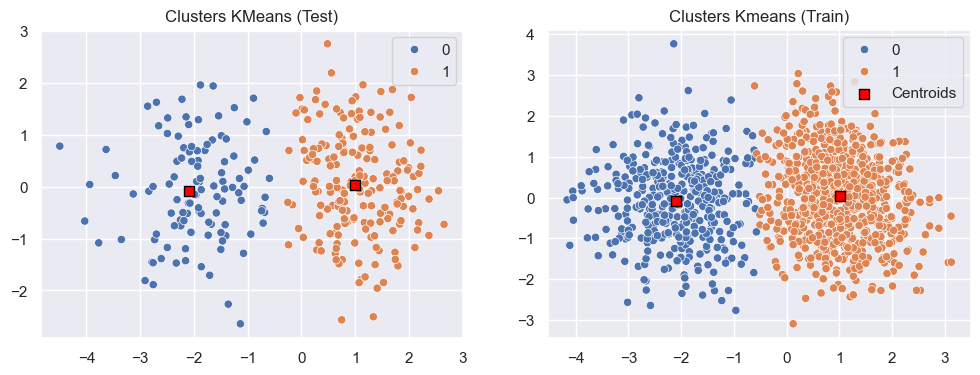

In [726]:
# Visuels des clusters X_train et X_test avec les centroïdes

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
sns.scatterplot(
    x=X_test_pca[:, 0],
    y=X_test_pca[:, 1],
    hue=test_labels,
    ax=ax[0]
)

ax[0].scatter(
    centroids[:, 0],
    centroids[:, 1],
    s=50,
    c='red',
    edgecolors='black',
    marker='s',
    label='Centroids',
)

ax[0].set_title("Clusters KMeans (Test)")

sns.scatterplot(
    x=X_train_pca[:, 0],
    y=X_train_pca[:, 1],
    hue=train_labels,
    ax=ax[1]
)
ax[1].set_title('Clusters Kmeans (Train)')

ax[1].scatter(
    centroids[:, 0],
    centroids[:, 1],
    s=50,
    c='red',
    edgecolors='black',
    marker='s',
    label='Centroids',
)

plt.legend()
               
plt.show()

In [740]:
print(f'Rapport sur les prédictions Kmeans :')
print(classification_report(y_test, test_labels))
print('Matrice de confusion Kmeans')
print(confusion_matrix(y_test, test_labels))

Rapport sur les prédictions Kmeans :
              precision    recall  f1-score   support

       False       0.97      0.99      0.98       110
        True       0.99      0.98      0.99       190

    accuracy                           0.99       300
   macro avg       0.98      0.99      0.99       300
weighted avg       0.99      0.99      0.99       300

Matrice de confusion Kmeans
[[109   1]
 [  3 187]]


In [728]:
# Interpréter les clusters

pd.crosstab(y_train, train_labels, colnames=['cluster'])

cluster,0,1
is_genuine,,
False,378,12
True,10,800


In [729]:
# Peux-tu voir les différences ?
# KMeans est un algorithme non supervisé qui regroupe les observations en fonction des distances entre les variables explicatives, 
# sans utiliser la variable cible is_genuine. Il ne produit pas de probabilités et ne constitue pas un modèle de classification supervisée.

# Dans ce contexte, bien que KMeans ne soit pas conçu pour la classification, il permet de révéler une structure naturelle dans les données. 
# Les clusters obtenus montrent une forte correspondance avec la variable cible, ce qui indique que les observations sont naturellement 
# séparables dans l’espace des variables.

# Du coup, cet algo est-il utile (voir pertinent) pour cette étude ?
# Sur cette étude, une approche supervisée est plus adaptée car la variable cible est connue.

# Sélection du meilleur modèle

Mais alors, quel est le meilleur modèle pour résoudre ce problème ?

Pour répondre à cette question, il vous faut bien comprendre l'intérêt de chacune des métriques d'évaluation qui existent pour ce type de problème.

Vous me voyez venir... 😎 : StatQuest !!! 🤩
* [Machine Learning Fundamentals: Sensitivity and Specificity
](https://youtu.be/vP06aMoz4v8)
* [Machine Learning Fundamentals: The Confusion Matrix](https://youtu.be/Kdsp6soqA7o)
* [ROC and AUC, Clearly Explained!](https://youtu.be/4jRBRDbJemM)

Vous avez aussi des petits modules sympathiques sur Sklearn qui vous machent grandement le travail:
* [Confusion Matrix](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.confusion_matrix.html)
* [Confusion Matrix Display](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.ConfusionMatrixDisplay.html)
* [Classification Report](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.classification_report.html)

A vous de jouer ! 🚀

In [730]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, ConfusionMatrixDisplay, classification_report

In [731]:
# Fonction qui retourne toutes les valeurs de score

def metrics(y_true, y_pred, y_hat_proba) :
    return {
        'Accuracy' : accuracy_score(y_true, y_pred),
        'Precision' : precision_score(y_true, y_pred),
         'Recall' : recall_score(y_true, y_pred),
         'F1' : f1_score(y_true, y_pred),
         'Roc_auc' : roc_auc_score(y_true, y_hat_proba)
        }

In [732]:
# Stocker les scores de chaque modèle

metrics_clf = metrics(y_test, y_pred_clf, y_hat_proba_clf)
metrics_knn = metrics(y_test, y_pred_knn, y_hat_proba_knn)
metrics_rf = metrics(y_test, y_pred_rf, y_hat_proba_rf)

In [733]:
# Faire un df pour la lisibilité

df_metrics = pd.DataFrame({
    'clf' : metrics_clf,
    'knn' : metrics_knn,
    'rf' : metrics_rf
}).T.style.highlight_max(axis=0)

df_metrics

,Accuracy,Precision,Recall,F1,Roc_auc
clf,0.993333,0.989583,1.000000,0.994764,0.999856
knn,0.986667,0.979381,1.000000,0.989583,0.995215
rf,0.990000,0.984456,1.000000,0.992167,0.999761


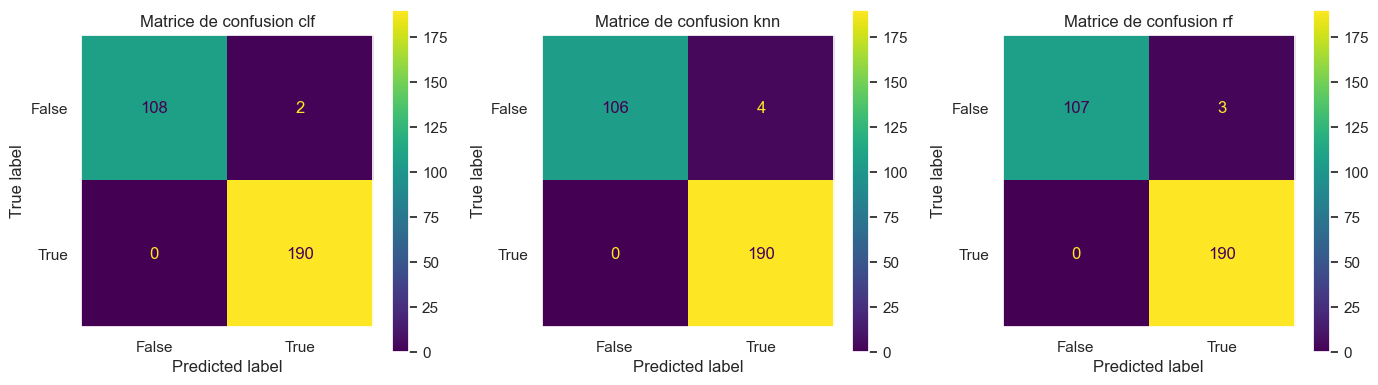

In [734]:
# Comparaison des matrices de confusion

disp_clf = ConfusionMatrixDisplay(confusion_matrix=cm_clf, display_labels=clf.classes_)
disp_knn = ConfusionMatrixDisplay(confusion_matrix=cm_knn, display_labels=knn.classes_)
disp_rf = ConfusionMatrixDisplay(confusion_matrix=cm_rf, display_labels=rf.classes_)

fig, ax = plt.subplots(1, 3, figsize=(14, 4))

disp_clf.plot(ax=ax[0])
ax[0].set_title('Matrice de confusion clf')
ax[0].grid(False)


disp_knn.plot(ax=ax[1])
ax[1].set_title('Matrice de confusion knn')
ax[1].grid(False)


disp_rf.plot(ax=ax[2])
ax[2].set_title('Matrice de confusion rf')
ax[2].grid(False)


plt.tight_layout()
plt.show()

In [742]:
# Cross validation avec plusieurs splits

scoring = ['accuracy', 'precision', 'recall', 'f1', 'roc_auc']

from sklearn.model_selection import cross_validate

scores_clf = cross_validate(clf, X_train, y_train, cv=5, scoring=scoring)
scores_knn = cross_validate(knn, X_train, y_train, cv=5, scoring=scoring)
scores_rf = cross_validate(rf, X_train, y_train, cv=5, scoring=scoring)

df_cross_validate = pd.DataFrame({
    'clf' : pd.DataFrame(scores_clf).mean(),
    'knn' : pd.DataFrame(scores_knn).mean(),
    'rf': pd.DataFrame(scores_rf).mean()
})

df_cross_validate.T.style.highlight_max(axis=0)

,fit_time,score_time,test_accuracy,test_precision,test_recall,test_f1,test_roc_auc
clf,0.007842,0.031611,0.989167,0.987782,0.996296,0.992011,0.998607
knn,0.002919,0.044036,0.989167,0.990176,0.993827,0.991992,0.992490
rf,0.339545,0.067543,0.991667,0.991433,0.996296,0.993846,0.999319


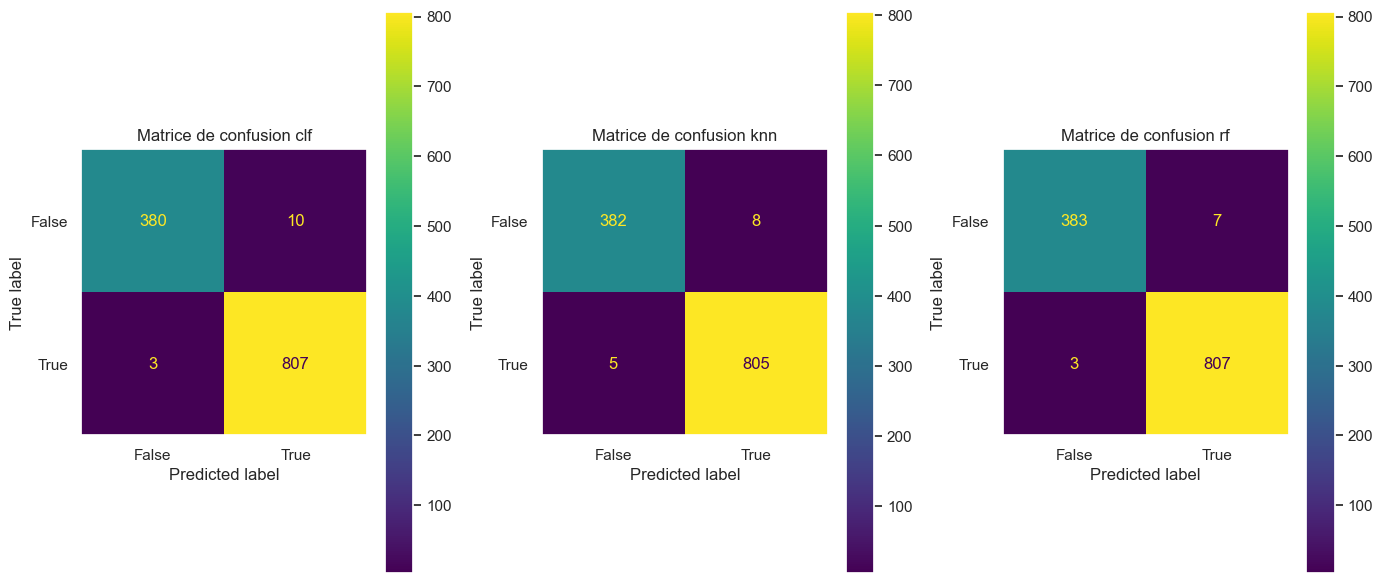

In [743]:
# Matrice de confusion des différents modèles sur plusieurs splits 

from sklearn.model_selection import cross_val_predict

def cm_cvp (model):
    y_pred = cross_val_predict(model, X_train, y_train, cv=5)
    return confusion_matrix(y_train, y_pred)
    
fig, ax = plt.subplots(1, 3, figsize=(14, 6))

cm_clf = ConfusionMatrixDisplay(confusion_matrix=cm_cvp(clf), display_labels=clf.classes_)
cm_clf.plot(ax=ax[0])
ax[0].set_title('Matrice de confusion clf')

cm_knn = ConfusionMatrixDisplay(confusion_matrix=cm_cvp(knn), display_labels=knn.classes_)
cm_knn.plot(ax=ax[1])
ax[1].set_title('Matrice de confusion knn')


cm_rf = ConfusionMatrixDisplay(confusion_matrix=cm_cvp(rf), display_labels=rf.classes_)
cm_rf.plot(ax=ax[2])
ax[2].set_title('Matrice de confusion rf')


for a in ax :
    a.grid(False)

plt.tight_layout()
plt.show()

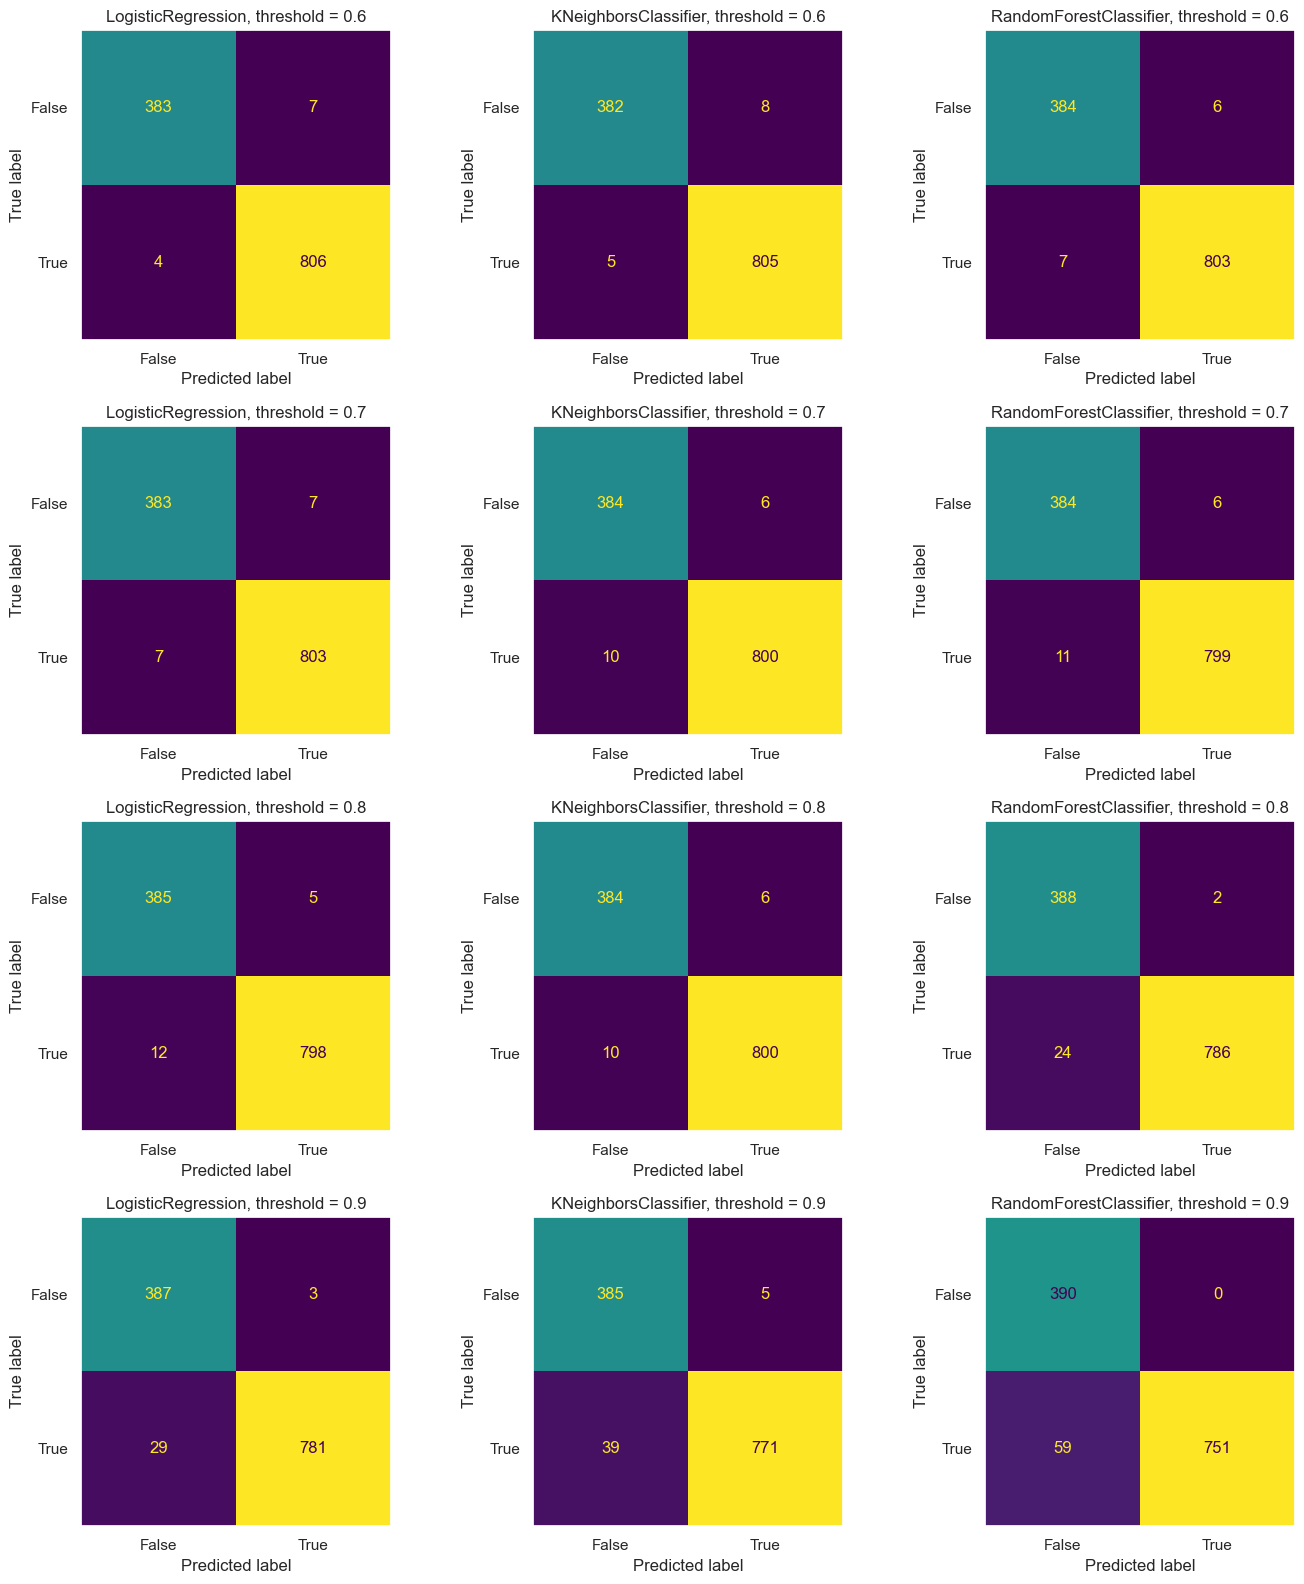

In [750]:
def cm_cvp_threshold(model, X, y, threshold=0.5, cv=5):
    
    y_proba = cross_val_predict(
        model,
        X,
        y,
        cv=cv,
        method="predict_proba"
    )[:, 1]
    
    y_pred = (y_proba >= threshold).astype(int)
    
    return confusion_matrix(y, y_pred)

fig, ax = plt.subplots(4, 3, figsize=(14, 16))

thresholds = [0.6, 0.7, 0.8, 0.9]
models = [clf, knn, rf]

for i, t in enumerate(thresholds):
    
    for j, model in enumerate(models):
        
        cm = cm_cvp_threshold(model, X_train, y_train, threshold=t)
        
        ConfusionMatrixDisplay(
            confusion_matrix=cm,
            display_labels=model.classes_
        ).plot(ax=ax[i, j], colorbar=False)
        
        ax[i, j].set_title(f"{type(model).__name__}, threshold = {t}")

for row in ax :
    for a in row :
        a.grid(False)
    
plt.tight_layout()
plt.show()

In [ ]:
# Le réglage du seuil de classification n’apporte qu’une amélioration marginale des performances, 
# ce qui s’explique par une forte séparabilité des classes. Le seuil par défaut (0.5) est donc conservé.

In [ ]:
# Les 3 modèles étants très performants, la regression logistique est retenue pour sa stabilité et son interprétabilité

# Sauvegarde du meilleur modèle

**_ATTENTION_** :
```
Sauvegarder un modèle implique de sauvegarder aussi les étapes de préprocessing des données.
Dans votre cas, vous devez donc inclure, à minima, votre StandardScaler.
```
Voir [`make_pipeline`](https://scikit-learn.org/stable/modules/generated/sklearn.pipeline.make_pipeline.html) pour plus d'infos.

In [ ]:
from sklearn.pipeline import make_pipeline
from sklearn.impute import SimpleImputer
import joblib

# Repartir des données brutes
X = df.drop(columns='is_genuine')
y = df['is_genuine']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Utilisez make_pipeline pour inclure toutes les étapes nécessaires
# à la prédiction de si un billet est vrai ou faux.

# Pipeline                  
pipe = make_pipeline(
    SimpleImputer(strategy='mean'),
    StandardScaler(),
    LogisticRegression(max_iter=1000)
)

# Entrainement du modèle
pipe.fit(X_train, y_train)

# Sauvegardez votre modèle à l'aide de la librairie joblib.
joblib.dump(pipe, "model_billet.pkl")

# Sauvegarde des variables explicatives du modèle
features = df.columns.drop('is_genuine')
joblib.dump(features, 'features.pkl')

In [ ]:
# Vérification du modèle sauvegardé

y_pred = pipe.predict(X_test)
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

# Test Production

In [ ]:
df_prod = pd.read_csv('C:/Users/Utilisateur/Desktop/OpenClassRooms/Projet 12/billets_production.csv')
df_prod.head()

In [ ]:
model = joblib.load('model_billet.pkl')
model

In [ ]:
features = joblib.load("features.pkl")
features

In [ ]:
X = df_prod[features]
predictions = model.predict(X)
df_prod['predictions'] = predictions
df_prod

In [ ]:
model.predict_proba(X)[:, 1]

In [ ]:
df_test = pd.read_csv('C:/Users/Utilisateur/Desktop/OpenClassRooms/Projet 12/billets_test.csv')
df_test

In [ ]:
X = df_test[features]
predictions = model.predict(X)
df_test['predictions'] = predictions
df_test

In [ ]:
model.predict_proba(X)[:, 1]